In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.plot_utils import setup_matplotlib

from scipy.spatial.transform import Rotation as R

In [2]:
setup_matplotlib()

In [3]:
experiments = ['square', 'random', 'chirp', 'melon']
runs = [1, 2, 3, 4]
df_real_dict = {}

for experiment in experiments:
    file_name = f'{experiment}_20251017'
    for run in runs:
        try:
            file_name_real = f'{file_name}_run{run}.csv'
            df_real = pd.read_csv(os.path.join('../data/train/', file_name_real))
            # Store dynamically
            df_real_dict[f'{experiment}_run{run}'] = df_real
        except Exception as e:
            print(e)
            continue

[Errno 2] No such file or directory: '../data/real/processed/train/square_20251017_run4.csv'
[Errno 2] No such file or directory: '../data/real/processed/train/random_20251017_run4.csv'
[Errno 2] No such file or directory: '../data/real/processed/train/chirp_20251017_run4.csv'
[Errno 2] No such file or directory: '../data/real/processed/train/melon_20251017_run4.csv'


### Comments on unmodelled dynamics effects

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


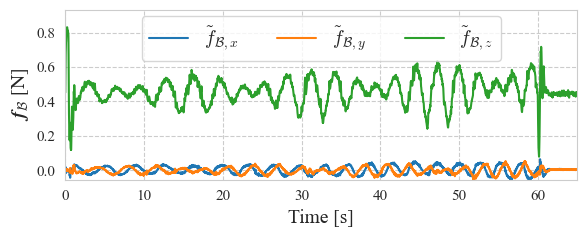

In [10]:
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
import numpy as np

m = 0.045

# Load run
df = df_real_dict["melon_run1"]

# Normalize quaternion
quat = df[["qx", "qy", "qz", "qw"]].to_numpy()
quat /= np.linalg.norm(quat, axis=1, keepdims=True)

# World-frame accel → Body frame
ag_wf = df[["ax", "ay", "az"]].to_numpy()
r = R.from_quat(quat)
ag_bf = r.apply(ag_wf, inverse=True)       # accel in body frame

df[["ax_body", "ay_body", "az_body"]] = ag_bf

# Compute force estimate
F_bf = m * ag_bf    # approximate "force" along x,y,z in body frame

# Plot
plt.figure(figsize=(6,2.5))
plt.plot(df['t'], F_bf[:,0], label=r"$\tilde{f}_{\mathcal{B},x}$")
plt.plot(df['t'], F_bf[:,1], label=r"$\tilde{f}_{\mathcal{B},y}$")
plt.plot(df['t'], F_bf[:,2], label=r"$\tilde{f}_{\mathcal{B},z}$")
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.02))
plt.xlabel("Time [s]")
plt.ylabel(r"$\boldsymbol{f}_{\mathcal{B}}$ [N]")
plt.ylim(F_bf.min(), F_bf.max()+0.1)
plt.grid(True)
plt.tight_layout()
plt.savefig('forces_non_idealities.pdf')
plt.show()


# $k_F$ identification

In [11]:
def compute_thrust_signals(df, m=0.045, g=9.81):
    # Normalize quaternion
    quat = df[["qx", "qy", "qz", "qw"]].to_numpy()
    quat /= np.linalg.norm(quat, axis=1, keepdims=True)

    # Transform accel to body frame
    ag_wf = df[["ax", "ay", "az"]].to_numpy()
    r = R.from_quat(quat)
    ag_bf = r.apply(ag_wf, inverse=True)

    df[["ax_body", "ay_body", "az_body"]] = ag_bf

    # IMU-based thrust
    T_bf = m * (ag_bf[:, 2])
    df["T_bf"] = T_bf

    # Motor-based thrust proxy
    motor_cols_rads2 = [c for c in df.columns if c.endswith("_rads2")]
    T_mot = df[motor_cols_rads2].sum(axis=1)
    df["T_mot"] = T_mot

    return df

In [12]:
# train_keys = [k for k in df_real_dict.keys() if not k.endswith("4")]
# test_keys  = [k for k in df_real_dict.keys() if k.endswith("4")]
train_keys = [k for k in df_real_dict.keys() if not "melon" in k]
test_keys  = [k for k in df_real_dict.keys() if "melon" in k]


print("Training:", train_keys)
print("Testing :", test_keys)

# recompute thrust for all
df_train_list = []
df_test_list  = []

for k in train_keys:
    df = compute_thrust_signals(df_real_dict[k].copy())
    df_train_list.append(df[["t","T_bf", "T_mot"]])

for k in test_keys:
    df = compute_thrust_signals(df_real_dict[k].copy())
    df_test_list.append(df[["t", "T_bf", "T_mot"]])

df_train = pd.concat(df_train_list, ignore_index=True).dropna()
df_test  = pd.concat(df_test_list, ignore_index=True).dropna()

print("Train samples:", len(df_train))
print("Test samples :", len(df_test))

Training: ['square_run1', 'square_run2', 'square_run3', 'random_run1', 'random_run2', 'random_run3', 'chirp_run1', 'chirp_run2', 'chirp_run3']
Testing : ['melon_run1', 'melon_run2', 'melon_run3']
Train samples: 41700
Test samples : 19497


In [13]:
from sklearn.linear_model import LinearRegression

X_train = df_train["T_mot"].values.reshape(-1, 1)
y_train = df_train["T_bf"].values

reg = LinearRegression(fit_intercept=False).fit(X_train, y_train)

Kf = reg.coef_[0]
bias = reg.intercept_

print("========= Fitted Model ========")
print(f"Kf  = {Kf}")
print(f"bias = {bias}")
print("================================")

========= Fitted Model ========
Kf  = 3.7217875636633536e-08
bias = 0.0


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


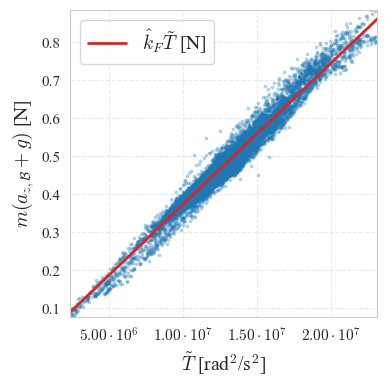

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))   # square figure
ax = plt.gca()

# ------------------------------------------------------------
# Scatter: Measured thrust T = m(a_zB + g)
# ------------------------------------------------------------
ax.scatter(
    df_train["T_mot"],
    df_train["T_bf"],
    s=3, alpha=0.25,
    label=None,
    rasterized=True
)

# ------------------------------------------------------------
# Regression line: T = k_F * T_tilde
# ------------------------------------------------------------
x_line = np.linspace(df_train["T_mot"].min(), df_train["T_mot"].max(), 300)
y_line = Kf * x_line

ax.plot(
    x_line, y_line, linewidth=2, color="tab:red",
    label=r"$\hat{k}_F \tilde{{T}}$ [N]"
)

# ------------------------------------------------------------
# Axis labels consistent with the paper
# ------------------------------------------------------------
ax.set_xlabel(r"$\tilde{T}$ [rad$^2$/s$^2$]")
ax.set_ylabel(r"$m(a_{z,\mathcal{B}} + g)$ [N]")

# ------------------------------------------------------------
# Custom scientific notation ONLY for x-axis (as you requested)
# Format: 3.8·10^{-8}
# ------------------------------------------------------------
def latex_sci(x):
    if x == 0:
        return "$0$"
    power = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**power
    return rf"${coeff:.2f}\cdot 10^{{{power}}}$"

ax.ticklabel_format(style='plain')  # disable default sci-notation
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: latex_sci(v)))

# Y-axis uses standard numeric formatting
# (so thrust in Newtons remains readable)

# ------------------------------------------------------------
# Square aspect ratio in data coordinates
# ------------------------------------------------------------
x_range = df_train["T_mot"].max() - df_train["T_mot"].min()
y_range = df_train["T_bf"].max() - df_train["T_bf"].min()
ax.set_aspect(x_range / y_range)

ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig('kf_leastsquare.pdf')
plt.show()


Validation step:  $J_{xx} \dot{\omega}_x = k_F T$

In [15]:
import numpy as np
import pandas as pd
import scipy.interpolate as si

def compute_torque_signals(df, Kf, L=0.0353):
    """
    df must contain columns:
    t, wx, wy, wz, m1_erpm ... m4_erpm
    """

    t = df["t"].to_numpy()
    dt = 0.01
    wx = df["wx"].to_numpy()
    wy = df["wy"].to_numpy()
    wz = df["wz"].to_numpy()

    # ---------------------------
    # Motor torques (X config)
    # ---------------------------
    m1, m2, m3, m4 = (df[c].to_numpy() for c in [
        "m1_rads2", "m2_rads2", "m3_rads2", "m4_rads2"
    ])

    tau_x_id = L * Kf * ((m3 + m4) - (m1 + m2))
    tau_y_id = L * Kf * ((m2 + m3) - (m1 + m4))
    # NOTE: we skip tau_z (reaction torques) unless you want it

    # ---------------------------
    # Angular accelerations
    # ---------------------------
    wxd = pd.Series(wx).diff() / dt
    wyd = pd.Series(wy).diff() / dt
    wzd = pd.Series(wz).diff() / dt

    out = pd.DataFrame({
        "t": t,
        "tau_x_id": tau_x_id,
        "tau_y_id": tau_y_id,
        "wxd": wxd,
        "wyd": wyd,
        "wzd": wzd
    })

    return out

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter

J_xx = 2.3951e-5
L = 0.0353

class OneDecimalScalarFormatter(ScalarFormatter):
    def _set_format(self):
        # force exactly 1 decimal digit (e.g., -5.0, 0.0, 3.5)
        self.format = "%1.1f"

def plot_torque_x_comparison(df_real_dict, pattern, Kf,
                           L=L, J_xx=J_xx, figsize=(6, 2.5), xlim=None, ylim=None):
    """
    Compute and plot τ_x comparison for all runs containing `pattern`.

    Produces:
        - Mean ± std envelope for measured τ_x = J_xx * wx_dot
        - Mean ± std envelope for identified τ_x = L*Kf*(...)
        - Uses time t on the x-axis (aligned/truncated)
    """

    outs = []

    # ---------------------------------------------------------------
    # 1) Collect torque signals for all runs matching pattern
    # ---------------------------------------------------------------
    for k, df in df_real_dict.items():
        if pattern.lower() in k.lower():
            out = compute_torque_signals(df, Kf=Kf, L=L)
            out["tau_x_meas"] = J_xx * out["wxd"]
            outs.append(out[["t", "tau_x_meas", "tau_x_id"]])

    if len(outs) == 0:
        print(f"No runs found matching pattern: '{pattern}'")
        return

    # ---------------------------------------------------------------
    # 2) Align lengths by truncating to the shortest run
    # ---------------------------------------------------------------
    min_len = min(len(o) for o in outs)
    outs = [o.iloc[:min_len].reset_index(drop=True) for o in outs]

    # All runs share the same x-axis now
    t = outs[0]["t"].to_numpy()

    # ---------------------------------------------------------------
    # 3) Stack into matrices [N_runs × N_samples]
    # ---------------------------------------------------------------
    meas_stack = np.stack([o["tau_x_meas"].to_numpy() for o in outs], axis=0)
    id_stack   = np.stack([o["tau_x_id"].to_numpy() for o in outs], axis=0)

    # ---------------------------------------------------------------
    # 4) Mean & std
    # ---------------------------------------------------------------
    meas_mean = meas_stack.mean(axis=0)
    meas_std  = meas_stack.std(axis=0)

    id_mean = id_stack.mean(axis=0)
    id_std  = id_stack.std(axis=0)

    # ---------------------------------------------------------------
    # 5) Plot: Torque comparison
    # ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Make outer box light grey instead of black
    for spine in ax.spines.values():
        spine.set_edgecolor("lightgray")

    # Measured torque (J_xx * ω̇ₓ)
    ax.plot(t, meas_mean, label=r"$\tilde \tau_x$")
    # ax.fill_between(
    #     t,
    #     meas_mean - meas_std,
    #     meas_mean + meas_std,
    #     alpha=0.25
    # )

    # Identified torque (L Kf (...) )
    ax.plot(t, id_mean, label=r"$k_F\,L\,(-\Omega_1^2-\Omega_2^2+\Omega_3^2+\Omega_4^2)$")
    # ax.fill_between(
    #     t,
    #     id_mean - id_std,
    #     id_mean + id_std,
    #     alpha=0.25
    # )

    # Y-limits (same logic as τ_y)
    ymin = (id_mean - id_std).min()
    ymax = (id_mean + id_std).max() + 5e-3
    ax.set_ylim(ymin, ymax)

    # ---------------------------------------------------------------
    # 6) Y-axis formatting: 1 decimal + "1e-3" style offset
    # ---------------------------------------------------------------
    formatter = OneDecimalScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-1, 1))   # triggers ×10^{-3}, ×10^{-4}, etc.
    formatter.set_scientific(True)
    formatter.set_useOffset(True)
    ax.yaxis.set_major_formatter(formatter)

    # ---------------------------------------------------------------
    # 7) Legend and labels
    # ---------------------------------------------------------------
    ax.legend(loc="upper center", ncols=2, frameon=True)

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Torque [Nm]")
    ax.grid(True, alpha=0.4)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    fig.tight_layout()
    fig.savefig("figures/torque_x_timeseries_mean_std.pdf")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_x_timeseries_mean_std.pdf'

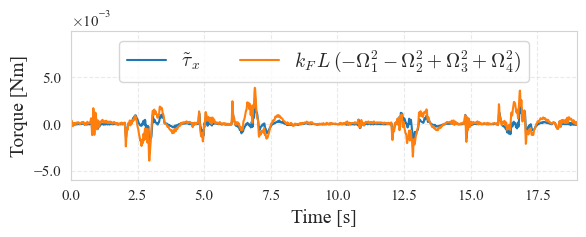

In [17]:
plot_torque_x_comparison(df_real_dict, pattern="square", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_x_timeseries_mean_std.pdf'

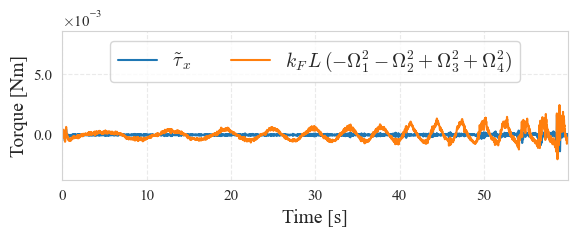

In [18]:
plot_torque_x_comparison(df_real_dict, pattern="chirp", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_x_timeseries_mean_std.pdf'

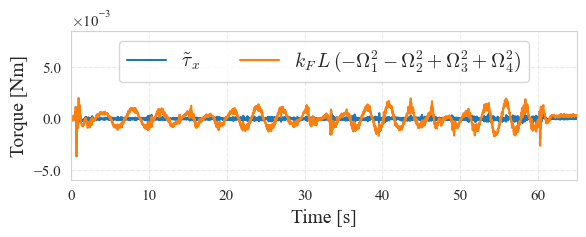

In [19]:
#plot_torque_x_comparison(df_real_dict, pattern="random", Kf=Kf)
plot_torque_x_comparison(df_real_dict, pattern="melon", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_x_timeseries_mean_std.pdf'

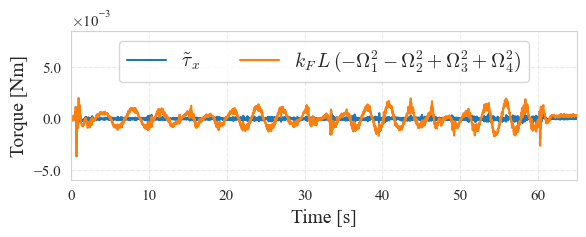

In [20]:
plot_torque_x_comparison(df_real_dict, pattern="melon", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_x_timeseries_mean_std.pdf'

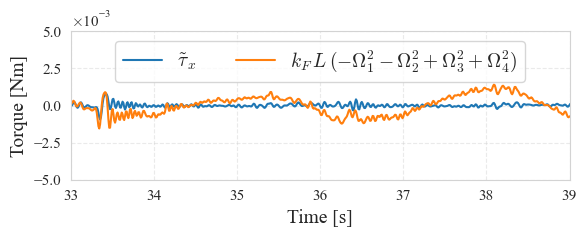

In [21]:
plot_torque_x_comparison(df_real_dict, pattern="melon", Kf=Kf, xlim=[33, 39], ylim=[-5e-3, 5e-3])

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


J_yy = 2.3951e-5
L = 0.0353

def plot_torque_y_comparison(df_real_dict, pattern, Kf,
                             L=L, J_yy=J_yy, figsize=(6,2.5)):
    """
    Compute and plot τ_y comparison for all runs containing `pattern`.
    """

    outs = []

    # ---------------------------------------------------------------
    # 1) Collect torque signals for all runs matching pattern
    # ---------------------------------------------------------------
    for k, df in df_real_dict.items():
        if pattern.lower() in k.lower():
            out = compute_torque_signals(df, Kf=Kf, L=L)
            out["tau_y_meas"] = J_yy * out["wyd"]
            outs.append(out[["t", "tau_y_meas", "tau_y_id"]])

    if len(outs) == 0:
        print(f"No runs found matching pattern: '{pattern}'")
        return

    # ---------------------------------------------------------------
    # 2) Align lengths
    # ---------------------------------------------------------------
    min_len = min(len(o) for o in outs)
    outs = [o.iloc[:min_len].reset_index(drop=True) for o in outs]
    t = outs[0]["t"].to_numpy()

    # ---------------------------------------------------------------
    # 3) Stack
    # ---------------------------------------------------------------
    meas_stack = np.stack([o["tau_y_meas"].to_numpy() for o in outs], axis=0)
    id_stack   = np.stack([o["tau_y_id"].to_numpy() for o in outs], axis=0)

    # ---------------------------------------------------------------
    # 4) Mean & std
    # ---------------------------------------------------------------
    meas_mean = meas_stack.mean(axis=0)
    meas_std  = meas_stack.std(axis=0)
    id_mean = id_stack.mean(axis=0)
    id_std  = id_stack.std(axis=0)

    # ---------------------------------------------------------------
    # 5) Plot
    # ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Make outer box light grey instead of black
    for spine in ax.spines.values():
        spine.set_edgecolor("lightgray")  # or any color you prefer

    ax.plot(t, meas_mean, label=r"$\tilde \tau_y$")
    ax.fill_between(t, meas_mean - meas_std, meas_mean + meas_std, alpha=0.25)

    ax.plot(t, id_mean, label=r"$k_F\,L\,(-\Omega_1^2+\Omega_2^2+\Omega_3^2-\Omega_4^2)$")
    ax.fill_between(t, id_mean - id_std, id_mean + id_std, alpha=0.25)

    # ---------------------------------------------------------------
    # 6) Y-axis formatting: 1 decimal + "1e-3" style offset
    # ---------------------------------------------------------------
    formatter = OneDecimalScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-1, 1))   # small values → show 1e-3, 1e-4, etc.
    formatter.set_scientific(True)       # enable scientific mode
    formatter.set_useOffset(True)        # this gives you the nice ×1e-3 text

    ax.yaxis.set_major_formatter(formatter)

    # ---------------------------------------------------------------
    # 7) Legend without box
    # ---------------------------------------------------------------
    ax.legend(loc="upper center", ncols=2, frameon=True)

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Torque [Nm]")
    plt.ylim([(id_mean - id_std).min(axis=0), (id_mean + id_std).max(axis=0)+5e-3])
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    fig.savefig("figures/torque_y_timeseries_mean_std.pdf")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_y_timeseries_mean_std.pdf'

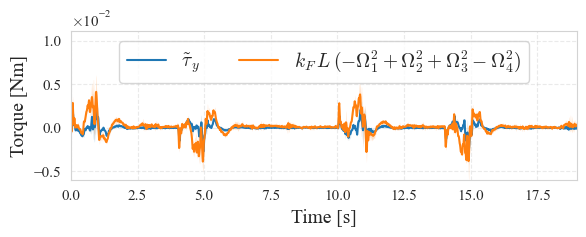

In [23]:
plot_torque_y_comparison(df_real_dict, pattern="square", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_y_timeseries_mean_std.pdf'

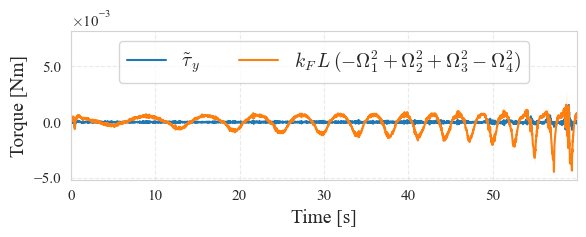

In [24]:
plot_torque_y_comparison(df_real_dict, pattern="chirp", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_y_timeseries_mean_std.pdf'

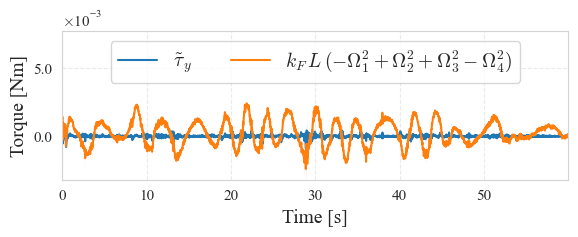

In [25]:
plot_torque_y_comparison(df_real_dict, pattern="random", Kf=Kf)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/torque_y_timeseries_mean_std.pdf'

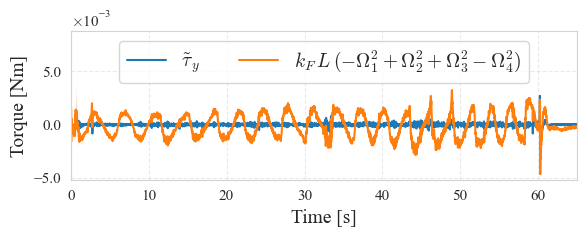

In [26]:
plot_torque_y_comparison(df_real_dict, pattern="melon", Kf=Kf)

In [27]:
def plot_thrust_timeseries_mean(df_test_list, kF, figsize=(6,2.5), save=True):
    """
    Plot mean ± std thrust for the test experiments.

    df_test_list: list of DataFrames (each with columns t, T_bf, T_mot)
    """

    # ------------------------------------------------------------
    # 1. Align runs by truncating to the shortest sequence
    # ------------------------------------------------------------
    min_len = min(len(df) for df in df_test_list)
    dfs = [df.iloc[:min_len].reset_index(drop=True) for df in df_test_list]

    # Common time axis (all runs have similar t)
    t = dfs[0]["t"].values

    # ------------------------------------------------------------
    # 2. Stack measured thrust and model thrust
    # ------------------------------------------------------------
    T_meas_stack  = np.stack([df["T_bf"].values           for df in dfs], axis=0)
    T_model_stack = np.stack([kF * df["T_mot"].values     for df in dfs], axis=0)

    # ------------------------------------------------------------
    # 3. Compute mean + std
    # ------------------------------------------------------------
    T_meas_mean  = T_meas_stack.mean(axis=0)
    T_meas_std   = T_meas_stack.std(axis=0)

    T_model_mean = T_model_stack.mean(axis=0)
    T_model_std  = T_model_stack.std(axis=0)

    # ------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    # --- Measured thrust: mean + std ---
    ax.plot(t, T_meas_mean, linewidth=1.5,
            label=r"$\tilde {f}_{\mathcal{B},z}$")

    ax.fill_between(
        t,
        T_meas_mean - T_meas_std,
        T_meas_mean + T_meas_std,
        alpha=0.25,
    )

    # --- Model thrust: mean + std ---
    ax.plot(t, T_model_mean, linewidth=1.5, color="tab:orange",
            label=r"$k_F (\Omega_1^2 + \Omega_2^2 + \Omega_3^2 + \Omega_4^2)$")

    ax.fill_between(
        t,
        T_model_mean - T_model_std,
        T_model_mean + T_model_std,
        alpha=0.25,
        color="tab:orange"
    )

    # Labels
    ax.set_xlabel(r"Time $t$ [s]")
    ax.set_ylabel(r"Thrust [N]")

    # Grid + Legend
    ax.grid(True, alpha=0.4)
    ax.legend(ncols=2, loc="upper center")

    # Tight layout + save optional
    plt.tight_layout()
    plt.ylim([0.05, 1])

    if save:
        plt.savefig("thrust_timeseries_mean_std.pdf")

    plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


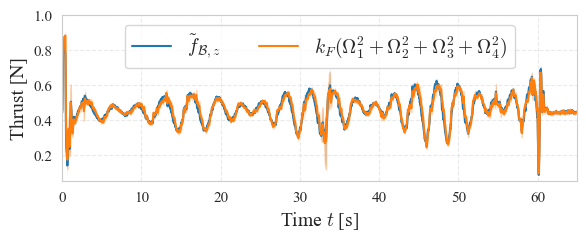

In [28]:
plot_thrust_timeseries_mean(df_test_list, Kf, save=True)

In [ ]:
def compute_yaw_torque_signals(df, Jz=3.2347e-5, dt=0.01):
    """
    Compute yaw torque signals (measured and motor-identified).

    Inputs:
        df : DataFrame with columns:
             t, wz, m1_rads2, m2_rads2, m3_rads2, m4_rads2
        KM : reaction torque coefficient
        Jz : inertia around body z-axis
        dt : sampling time

    Returns:
        DataFrame with:
            t, tau_z_meas, tau_z_id, wzd
    """

    # Extract time and yaw rate
    t  = df["t"].to_numpy()
    wz = df["wz"].to_numpy()

    # Finite-difference yaw acceleration
    wzd = pd.Series(wz).diff() / dt

    # -------------------------------
    #  Motor-based yaw torque
    # -------------------------------
    # Crazyflie spin directions (X-configuration):
    # m1: CW  →  +tau_z
    # m2: CCW →  -tau_z
    # m3: CW  →  +tau_z
    # m4: CCW →  -tau_z
    #
    # τ_z = K_M (Ω1² − Ω2² + Ω3² − Ω4²)
    #
    m1, m2, m3, m4 = (df[c].to_numpy() for c in [
        "m1_rads2", "m2_rads2", "m3_rads2", "m4_rads2"
    ])

    tau_z_mot = -( m1 - m2 + m3 - m4 )

    # -------------------------------
    #  Measured yaw torque
    # -------------------------------
    tau_z_meas = Jz * wzd

    # -------------------------------
    # Output DataFrame
    # -------------------------------
    return pd.DataFrame({
        "t": t,
        "tau_z_meas": tau_z_meas,
        "tau_z_mot": tau_z_mot,
        "wzd": wzd
    })

In [ ]:
# train_keys = [k for k in df_real_dict.keys() if not k.endswith("4")]
# test_keys  = [k for k in df_real_dict.keys() if k.endswith("4")]
train_keys = [k for k in df_real_dict.keys() if not "melon" in k]
test_keys  = [k for k in df_real_dict.keys() if "melon" in k]


print("Training:", train_keys)
print("Testing :", test_keys)

# recompute thrust for all
df_train_list = []
df_test_list  = []

for k in train_keys:
    df = compute_yaw_torque_signals(df_real_dict[k].copy())
    df_train_list.append(df[["t","tau_z_meas", "tau_z_mot"]])

for k in test_keys:
    df = compute_yaw_torque_signals(df_real_dict[k].copy())
    df_test_list.append(df[["t", "tau_z_meas", "tau_z_mot"]])

df_train = pd.concat(df_train_list, ignore_index=True).dropna()
df_test  = pd.concat(df_test_list, ignore_index=True).dropna()

print("Train samples:", len(df_train))
print("Test samples :", len(df_test))

In [ ]:
from sklearn.linear_model import LinearRegression

X_train = df_train["tau_z_mot"].values.reshape(-1, 1)
y_train = df_train["tau_z_meas"].values

reg = LinearRegression(fit_intercept=False).fit(X_train, y_train)

Km = reg.coef_[0]
bias = reg.intercept_

print("========= Fitted Model ========")
print(f"Kf  = {Km}")
print(f"bias = {bias}")
print("================================")

In [ ]:
N_start = 0
N_end = N_start + 500
(5e-11*df_test["tau_z_mot"])[N_start:N_end].plot()
(-df_test["tau_z_meas"][N_start:N_end]).plot()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))   # square figure
ax = plt.gca()

# ------------------------------------------------------------
# Scatter: Measured thrust T = m(a_zB + g)
# ------------------------------------------------------------
ax.scatter(
    df_train["tau_z_mot"],
    df_train["tau_z_meas"],
    s=3, alpha=0.25,
    label=None,
    rasterized=True
)

# ------------------------------------------------------------
# Regression line: T = k_F * T_tilde
# ------------------------------------------------------------
x_line = np.linspace(df_train["tau_z_mot"].min(), df_train["tau_z_mot"].max(), 300)
y_line = Km * x_line

ax.plot(
    x_line, y_line, linewidth=2, color="tab:red",
    label=r"$\hat{k}_F \tilde{{T}}$ [N]"
)

# ------------------------------------------------------------
# Axis labels consistent with the paper
# ------------------------------------------------------------
ax.set_xlabel(r"$\tilde{T}$ [rad$^2$/s$^2$]")
ax.set_ylabel(r"$m(a_{z,\mathcal{B}} + g)$ [N]")

# ------------------------------------------------------------
# Custom scientific notation ONLY for x-axis (as you requested)
# Format: 3.8·10^{-8}
# ------------------------------------------------------------
def latex_sci(x):
    if x == 0:
        return "$0$"
    power = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**power
    return rf"${coeff:.2f}\cdot 10^{{{power}}}$"

ax.ticklabel_format(style='plain')  # disable default sci-notation
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: latex_sci(v)))

# Y-axis uses standard numeric formatting
# (so thrust in Newtons remains readable)

# ------------------------------------------------------------
# Square aspect ratio in data coordinates
# ------------------------------------------------------------
x_range = df_train["tau_z_mot"].max() - df_train["tau_z_mot"].min()
y_range = df_train["tau_z_meas"].max() - df_train["tau_z_meas"].min()
ax.set_aspect(x_range / y_range)

ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_yaw_timeseries_mean(df_test_list, Km, figsize=(6,2.5), save=True):
    """
    Plot mean ± std of:
        - measured yaw torque τ_z = J_z * wz_dot
        - modeled yaw torque   = kM * tau_tilde_z
    in the same visual style as plot_torque_y_comparison.
    """

    # ---------------------------------------------------------------
    # 1) Align lengths
    # ---------------------------------------------------------------
    min_len = min(len(df) for df in df_test_list)
    dfs = [df.iloc[:min_len].reset_index(drop=True) for df in df_test_list]
    t = dfs[0]["t"].to_numpy()

    # ---------------------------------------------------------------
    # 2) Stack (with smoothing)
    # ---------------------------------------------------------------
    meas_stack = np.stack([
        df["tau_z_meas"].rolling(30, min_periods=1, center=True).mean().to_numpy()
        for df in dfs
    ], axis=0)

    model_stack = np.stack([
        Km * df["tau_z_mot"].rolling(30, min_periods=1, center=True).mean().to_numpy()
        for df in dfs
    ], axis=0)

    # ---------------------------------------------------------------
    # 3) Mean & std
    # ---------------------------------------------------------------
    meas_mean  = meas_stack.mean(axis=0)
    meas_std   = meas_stack.std(axis=0)
    model_mean = model_stack.mean(axis=0)
    model_std  = model_stack.std(axis=0)

    # ---------------------------------------------------------------
    # 4) Plot (identical style to torque-y)
    # ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Light grey axis box (same as torque-y)
    for spine in ax.spines.values():
        spine.set_edgecolor("lightgray")

    # Measured
    ax.plot(t, meas_mean, label=r"$\tilde \tau_z$")
    ax.fill_between(t, meas_mean - meas_std, meas_mean + meas_std, alpha=0.25)

    # Modeled
    ax.plot(t, model_mean, label=r"$k_M\,(-\Omega_1^2+\Omega_2^2-\Omega_3^2+\Omega_4^2)$")
    ax.fill_between(t, model_mean - model_std, model_mean + model_std,
                    alpha=0.25, color="tab:orange")

    # ---------------------------------------------------------------
    # 5) Y-axis formatting: scientific (same style)
    # ---------------------------------------------------------------
    formatter = OneDecimalScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-1, 1))
    formatter.set_scientific(True)
    formatter.set_useOffset(True)
    ax.yaxis.set_major_formatter(formatter)

    # ---------------------------------------------------------------
    # 6) Legend + labels + grid
    # ---------------------------------------------------------------
    ax.legend(loc="upper center", ncols=2, frameon=True)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Torque [Nm]")
    ax.grid(True, alpha=0.4)

    # Same y-limits behavior as torque-y:
    ymin = (model_mean - model_std).min()
    ymax = (model_mean + model_std).max() + 5e-4
    plt.ylim([ymin, ymax])

    fig.tight_layout()

    if save:
        fig.savefig("figures/torque_z_timeseries_mean_std.pdf")

    plt.show()

In [ ]:
plot_yaw_timeseries_mean(df_test_list, Km, save=True)

In [ ]:
plt.plot(df_real_dict["square_run1"]["wx"])
plt.plot(df_real_dict["chirp_run1"]["wx"])

In [ ]:
df_real_dict["melon_run1"]["wx"]